# RQ2 — Architecture & Representation Learning

**Research Question:** How does the integration of mechanistic blocks influence representation learning, generalisation, and interpretability compared to standard deep neural networks?

| Exp | What it measures | Systems |
|---|---|---|
| E1: In-distribution MSE | Raw reconstruction quality | Damped sine |
| E2: OOD generalisation | Mechanism vs memorisation | Damped sine (train amp=1, test amp=3) |
| E3: Long-horizon forecasting | Extrapolation stability | Two-body |
| E4: Interpretability | Learned alpha, step sizes, phase portrait | Damped sine |
| E5: Training efficiency | Convergence speed and parameter count | Damped sine |

In [1]:
import sys, os, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
import pytorch_lightning as pl
import warnings
warnings.filterwarnings('ignore')

# ── Set this to your mech-nn-master directory ────────────────────────
REPO_ROOT = '/Users/dorinai/Downloads/mech-nn-master'
sys.path.insert(0, REPO_ROOT)

from solver.ode_layer import ODEINDLayer
from fit.sine import SineDataModule, Method as SineMethod, Sine
import nbody.two_body_multi_sparse_sys as two_body_module

torch.set_printoptions(precision=6, linewidth=200, sci_mode=False)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
os.makedirs('rq2_results', exist_ok=True)
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

Using double precision solver
Building block diagonal A
run, logs/5, 5


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Device: cpu  |  PyTorch: 2.2.2


---
## Shared infrastructure: dataset, FlexSine, trainer

In [2]:
class ControlledSineDataset(torch.utils.data.Dataset):
    """y(t) = amplitude*sin(2t)*exp(-0.1t) + noise_std*N(0,1)"""
    def __init__(self, end=50.0, n_step=500, noise_std=0.5, amplitude=1.0, seed=0):
        rng   = np.random.default_rng(seed)
        t     = np.linspace(0, end, n_step)
        damp  = np.exp(-0.1 * t)
        clean = amplitude * np.sin(2 * t) * damp
        self.clean = torch.tensor(clean, dtype=torch.float64)
        self.y     = torch.tensor(clean + noise_std * rng.standard_normal(n_step),
                                  dtype=torch.float64)
    def __len__(self):       return 1
    def __getitem__(self, _): return self.y


class FlexSine(Sine):
    def __init__(self, n_step=500, seed=0):
        nn.Module.__init__(self)
        torch.manual_seed(seed); np.random.seed(seed)
        self.step_size = 0.1
        self.end = n_step * self.step_size
        self.n_step = n_step; self.order = 2; self.n_dim = 1
        self.bs = 1; self.n_iv = 0; self.iv_rhs = None
        dtype = torch.float64
        self.coeffs = nn.Parameter(
            torch.tensor(np.random.random((self.n_dim, n_step, self.order+1)), dtype=dtype))
        self.rhs   = torch.ones(1, 1, n_step, dtype=dtype)
        self.steps = nn.Parameter(
            torch.logit(self.step_size * torch.ones(1, n_step-1, self.n_dim)))
        self.ode = ODEINDLayer(bs=self.bs, order=self.order, n_ind_dim=self.n_dim,
                               n_iv=self.n_iv, n_step=n_step, n_iv_steps=1)


class FlexMethod(SineMethod):
    def __init__(self, n_step=500, lr=0.01, seed=0):
        pl.LightningModule.__init__(self)
        self.learning_rate = lr
        self.model = FlexSine(n_step=n_step, seed=seed)
        self.func_list=[]; self.y_list=[]
        self.funcp_list=[]; self.funcpp_list=[]; self.steps_list=[]
        self._loss_history = []

    def training_step(self, batch, batch_idx):
        result = super().training_step(batch, batch_idx)
        self._loss_history.append(result['loss'].item())
        return result


def make_trainer(n_epochs, silent=True):
    return pl.Trainer(
        max_epochs=n_epochs,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1, enable_progress_bar=not silent,
        enable_model_summary=False, log_every_n_steps=1)


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def eval_baseline(method, dataset):
    """MSE vs clean for any method."""
    method.eval()
    is_lstm = getattr(method, 'is_lstm', False)
    is_mnn  = isinstance(method, FlexMethod)
    with torch.no_grad():
        if is_mnn:
            _, u0, *_ = method()
            pred = u0.squeeze().float().cpu()
        elif is_lstm:
            x = dataset.y.unsqueeze(0).unsqueeze(-1)
            pred = method(x).squeeze().float().cpu()
        else:
            pred = method().squeeze().float().cpu()
    tgt = dataset.clean.float().cpu()
    L   = min(pred.shape[0], tgt.shape[0])
    return float(((pred[:L] - tgt[:L])**2).mean())


print('Infrastructure ready.')

Infrastructure ready.


---
## Baselines

All implemented in double precision to match FlexSine. Each takes a time vector or sequence and outputs y(t).

In [3]:
class MLPModel(nn.Module):
    def __init__(self, n_step=500, hidden=256, n_layers=4):
        super().__init__()
        t = torch.linspace(0, 1, n_step, dtype=torch.float64).unsqueeze(1)
        self.register_buffer('t', t)
        layers = [nn.Linear(1, hidden).double(), nn.Tanh()]
        for _ in range(n_layers - 1):
            layers += [nn.Linear(hidden, hidden).double(), nn.Tanh()]
        layers.append(nn.Linear(hidden, 1).double())
        self.net = nn.Sequential(*layers)
    def forward(self): return self.net(self.t).squeeze(-1)


class LSTMModel(nn.Module):
    def __init__(self, n_step=500, hidden=128, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(1, hidden, n_layers, batch_first=True).double()
        self.head = nn.Linear(hidden, 1).double()
    def forward(self, x=None):
        out, _ = self.lstm(x)
        return self.head(out).squeeze(-1).squeeze(0)


class ODEFunc(nn.Module):
    def __init__(self, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, hidden).double(), nn.Tanh(),
            nn.Linear(hidden, hidden).double(), nn.Tanh(),
            nn.Linear(hidden, 1).double())
    def forward(self, x, t):
        return self.net(torch.cat([x, t.expand_as(x)], dim=-1))


class NeuralODEModel(nn.Module):
    def __init__(self, n_step=500, end=50.0, hidden=128):
        super().__init__()
        self.func = ODEFunc(hidden)
        self.register_buffer('dt', torch.tensor(end / n_step, dtype=torch.float64))
        self.register_buffer('t_vals', torch.linspace(0, end, n_step, dtype=torch.float64))
        self.x0 = nn.Parameter(torch.zeros(1, 1, dtype=torch.float64))
    def forward(self, x=None):
        x = self.x0.clone()
        traj = [x.squeeze()]
        for i in range(len(self.t_vals) - 1):
            t = self.t_vals[i].reshape(1, 1)
            x = x + self.dt * self.func(x, t)
            traj.append(x.squeeze())
        return torch.stack(traj)


class BaselineMethod(pl.LightningModule):
    def __init__(self, model, lr=0.01, is_lstm=False):
        super().__init__()
        self.model = model; self.lr = lr; self.is_lstm = is_lstm
        self._loss_history = []
    def forward(self, x=None):
        return self.model(x) if self.is_lstm else self.model()
    def training_step(self, batch, _):
        y = batch.squeeze()
        x = y.unsqueeze(0).unsqueeze(-1) if self.is_lstm else None
        pred = self(x)
        loss = (pred - y).pow(2).mean()
        self.log('train_loss', loss, prog_bar=True)
        self._loss_history.append(loss.item())
        return loss
    def configure_optimizers(self):
        return torch.optim.Adam(self.parameters(), lr=self.lr)


def make_all_methods(n_step=500, lr=0.01, seed=0):
    return {
        'MNN':       FlexMethod(n_step=n_step, lr=lr, seed=seed),
        'MLP':       BaselineMethod(MLPModel(n_step=n_step),       lr=lr, is_lstm=False),
        'LSTM':      BaselineMethod(LSTMModel(n_step=n_step),      lr=lr, is_lstm=True),
        'NeuralODE': BaselineMethod(NeuralODEModel(n_step=n_step), lr=lr, is_lstm=False),
    }


# Verify parameter counts
methods_test = make_all_methods(n_step=500)
for name, m in methods_test.items():
    model_obj = m.model if hasattr(m, 'model') else m
    print(f'{name:12s}: {count_params(model_obj):>8,} params')

Using double precision solver
Building block diagonal A
MNN         :    1,999 params
MLP         :  198,145 params
LSTM        :  199,297 params
NeuralODE   :   17,026 params


---
## E1 — In-Distribution MSE
All models, same noisy damped sine, same training budget.

In [4]:
N_STEP   = 500
N_SEEDS  = 5
N_EPOCHS = 300
LR       = 0.01
NOISE    = 0.5
ORDER    = ['MNN', 'MLP', 'LSTM', 'NeuralODE']
MC       = {'MNN':'steelblue','MLP':'coral','LSTM':'seagreen','NeuralODE':'goldenrod'}

e1_records   = []
e1_histories = {n: [] for n in ORDER}

for seed in range(N_SEEDS):
    ds = ControlledSineDataset(n_step=N_STEP, noise_std=NOISE, seed=seed)
    dm = SineDataModule(ds)
    for name, method in make_all_methods(N_STEP, LR, seed).items():
        t0 = time.time()
        make_trainer(N_EPOCHS).fit(method, datamodule=dm)
        elapsed = time.time() - t0
        mse = eval_baseline(method, ds)
        e1_records.append({'model':name,'seed':seed,'mse':mse,'time_s':elapsed})
        e1_histories[name].append(method._loss_history)
        print(f'  [{name}] seed={seed}  mse={mse:.6f}  time={elapsed:.1f}s')

df_e1 = pd.DataFrame(e1_records)
df_e1g = df_e1.groupby('model').agg(
    mse_mean=('mse','mean'), mse_std=('mse','std'),
    time_mean=('time_s','mean')).reset_index()
df_e1g = df_e1g.set_index('model').loc[ORDER].reset_index()
df_e1g.to_csv('rq2_results/e1_indistribution.csv', index=False)
print('\nE1 Summary:')
print(df_e1g.to_string(index=False))

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Using double precision solver
Building block diagonal A


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  [MNN] seed=0  mse=0.049764  time=82.1s


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


...

  [MLP] seed=4  mse=0.049679  time=8.1s


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  [LSTM] seed=4  mse=0.254314  time=498.4s


`Trainer.fit` stopped: `max_epochs=300` reached.


  [NeuralODE] seed=4  mse=0.051416  time=51.0s

E1 Summary:
    model  mse_mean  mse_std  time_mean
      MNN  0.048115 0.007380  78.282389
      MLP  0.049832 0.000426   8.579867
     LSTM  0.245565 0.020783 154.419063
NeuralODE  0.052952 0.002240  44.162812


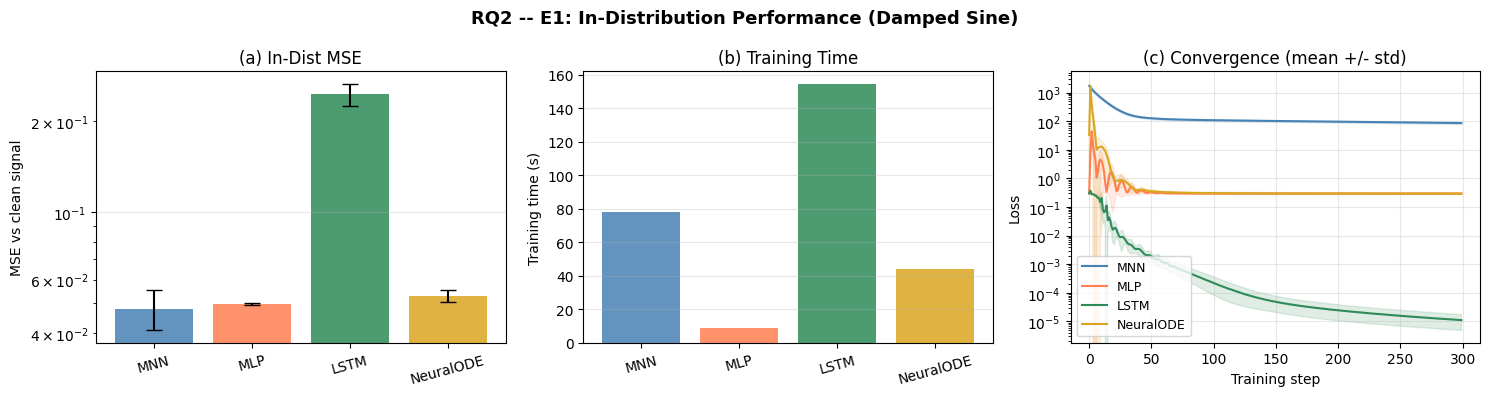

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.bar(df_e1g.model, df_e1g.mse_mean, yerr=df_e1g.mse_std, capsize=6,
       color=[MC[m] for m in df_e1g.model], alpha=0.85)
ax.set(ylabel='MSE vs clean signal', title='(a) In-Dist MSE', yscale='log')
ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(df_e1g.model, df_e1g.time_mean,
       color=[MC[m] for m in df_e1g.model], alpha=0.85)
ax.set(ylabel='Training time (s)', title='(b) Training Time')
ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
for name in ORDER:
    curves = e1_histories[name]
    if curves:
        arr = np.array([c for c in curves if len(c) == len(curves[0])])
        if arr.ndim == 2:
            ax.plot(arr.mean(axis=0), color=MC[name], linewidth=1.5, label=name)
            ax.fill_between(range(arr.shape[1]),
                            arr.mean(axis=0)-arr.std(axis=0),
                            arr.mean(axis=0)+arr.std(axis=0),
                            alpha=0.15, color=MC[name])
ax.set(xlabel='Training step', ylabel='Loss', yscale='log',
       title='(c) Convergence (mean +/- std)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('RQ2 -- E1: In-Distribution Performance (Damped Sine)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq2_results/e1_indistribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E2 — OOD Generalisation
Train amplitude=1.0, test amplitude=3.0.

In [6]:
e2_records = []

for seed in range(N_SEEDS):
    ds_train = ControlledSineDataset(n_step=N_STEP, noise_std=NOISE, amplitude=1.0, seed=seed)
    ds_ood   = ControlledSineDataset(n_step=N_STEP, noise_std=NOISE, amplitude=3.0, seed=seed+100)
    dm_train = SineDataModule(ds_train)

    for name, method in make_all_methods(N_STEP, LR, seed).items():
        make_trainer(N_EPOCHS).fit(method, datamodule=dm_train)
        mse_id  = eval_baseline(method, ds_train)
        mse_ood = eval_baseline(method, ds_ood)
        ratio   = mse_ood / (mse_id + 1e-10)
        e2_records.append({'model':name,'seed':seed,
                           'mse_id':mse_id,'mse_ood':mse_ood,'ratio':ratio})
        print(f'  [{name}] seed={seed}  id={mse_id:.6f}  ood={mse_ood:.6f}  ratio={ratio:.2f}x')

df_e2 = pd.DataFrame(e2_records)
df_e2g = df_e2.groupby('model').agg(
    id_mean=('mse_id','mean'), id_std=('mse_id','std'),
    ood_mean=('mse_ood','mean'), ood_std=('mse_ood','std'),
    ratio_mean=('ratio','mean'), ratio_std=('ratio','std')
).reset_index()
df_e2g = df_e2g.set_index('model').loc[ORDER].reset_index()
df_e2g.to_csv('rq2_results/e2_ood.csv', index=False)
print('\nE2 OOD Summary:')
print(df_e2g[['model','id_mean','ood_mean','ratio_mean']].to_string(index=False))

Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec

  [MNN] seed=0  id=0.049764  ood=0.250522  ratio=5.03x


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  [MLP] seed=0  id=0.049857  ood=0.448186  ratio=8.99x


...

  [MLP] seed=4  id=0.049679  ood=0.447403  ratio=9.01x


`Trainer.fit` stopped: `max_epochs=300` reached.
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


  [LSTM] seed=4  id=0.254314  ood=0.244439  ratio=0.96x


`Trainer.fit` stopped: `max_epochs=300` reached.


  [NeuralODE] seed=4  id=0.051416  ood=0.442957  ratio=8.62x

E2 OOD Summary:
    model  id_mean  ood_mean  ratio_mean
      MNN 0.048115  0.249980    5.289198
      MLP 0.049832  0.447203    8.974388
     LSTM 0.245565  0.245776    1.008415
NeuralODE 0.052952  0.449411    8.496896


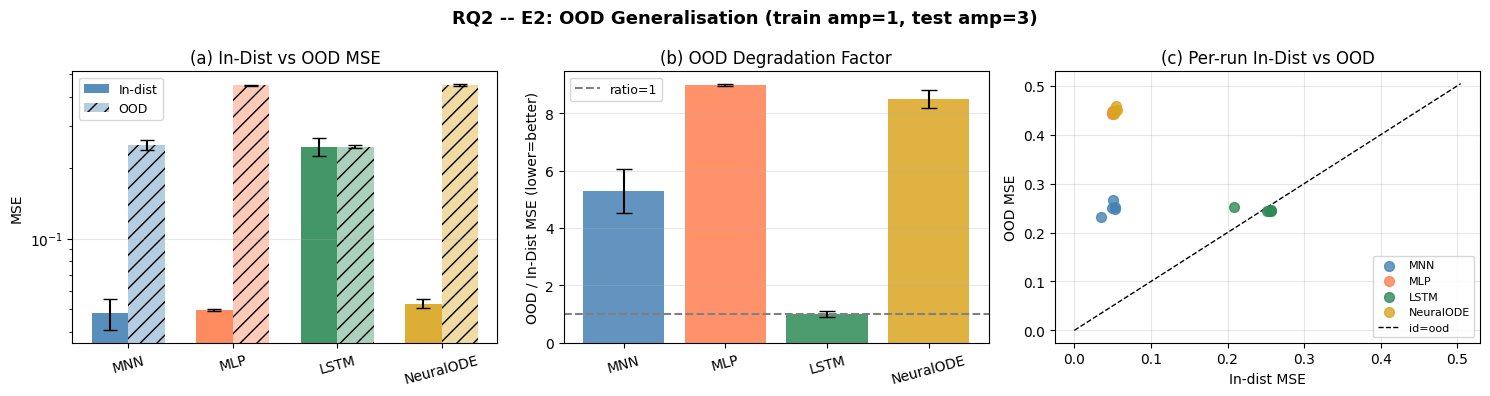

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
x = np.arange(len(df_e2g)); w = 0.35
ax.bar(x-w/2, df_e2g.id_mean,  w, yerr=df_e2g.id_std,
       color=[MC[m] for m in df_e2g.model], alpha=0.9, label='In-dist', capsize=5)
ax.bar(x+w/2, df_e2g.ood_mean, w, yerr=df_e2g.ood_std,
       color=[MC[m] for m in df_e2g.model], alpha=0.4, hatch='//', label='OOD', capsize=5)
ax.set_xticks(x); ax.set_xticklabels(df_e2g.model, rotation=15)
ax.set(ylabel='MSE', title='(a) In-Dist vs OOD MSE', yscale='log')
ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
ax.bar(df_e2g.model, df_e2g.ratio_mean, yerr=df_e2g.ratio_std, capsize=6,
       color=[MC[m] for m in df_e2g.model], alpha=0.85)
ax.axhline(1.0, linestyle='--', color='grey', label='ratio=1')
ax.set(ylabel='OOD / In-Dist MSE (lower=better)', title='(b) OOD Degradation Factor')
ax.tick_params(axis='x', rotation=15); ax.legend(fontsize=9); ax.grid(True, axis='y', alpha=0.3)

ax = axes[2]
for name in ORDER:
    sub = df_e2[df_e2.model==name]
    ax.scatter(sub.mse_id, sub.mse_ood, color=MC[name], s=50,
               label=name, zorder=3, alpha=0.8)
lim = max(df_e2.mse_id.max(), df_e2.mse_ood.max()) * 1.1
ax.plot([0, lim], [0, lim], 'k--', linewidth=1, label='id=ood')
ax.set(xlabel='In-dist MSE', ylabel='OOD MSE', title='(c) Per-run In-Dist vs OOD')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

fig.suptitle('RQ2 -- E2: OOD Generalisation (train amp=1, test amp=3)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq2_results/e2_ood.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E3 — Long-Horizon Forecasting (Two-Body)

Uses the exact run_inference loop from 2_two_body_test.ipynb.

In [9]:
BATCH_SIZE = 30
NS         = 50

tb_method, tb_dm = two_body_module.build_model(
    batch_size=BATCH_SIZE, solver_dbl=False, learning_rate=1e-4)

pl.Trainer(
    max_epochs=20,
    accelerator='gpu' if torch.cuda.is_available() else 'cpu',
    devices=1, check_val_every_n_epoch=10,
    log_every_n_steps=500, enable_model_summary=False,
).fit(tb_method, datamodule=tb_dm)

print('Two-body MNN trained.')

Using single precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Epoch 9: 100%|██████████| 63/63 [01:47<00:00,  0.59it/s, v_num=131, train_loss_step=0.00415, train_loss_epoch=0.00873]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 19: 100%|██████████| 63/63 [03:52<00:00,  0.27it/s, v_num=131, train_loss_step=0.0261, train_loss_epoch=0.00234, val_loss_step=0.00279, val_loss_epoch=0.00565]  
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 19: 100%|██████████| 63/63 [06:17<00:00,  0.17it/s, v_num=131, train_loss_step=0.0261, train_loss_epoch=0.0288, val_loss_step=0.027, val_loss_epoch=0.0241]    

`Trainer.fit` stopped: `max_epochs=20` reached.


Epoch 19: 100%|██████████| 63/63 [06:17<00:00,  0.17it/s, v_num=131, train_loss_step=0.0261, train_loss_epoch=0.0288, val_loss_step=0.027, val_loss_epoch=0.0241]
Two-body MNN trained.


In [10]:
@torch.no_grad()
def run_inference(method, x, v, steps):
    method.to(DEVICE)
    positions, velocities = [], []
    for step in range(steps):
        x, v = x.to(DEVICE), v.to(DEVICE)
        x_out, v_out = method.inference((x, v))
        x = x_out[:, 10:NS+10]
        v = v_out[:, 10:NS+10]
        positions.append(x_out[0, NS:NS+10].squeeze(0).cpu().numpy())
        velocities.append(v_out[0, NS:NS+10].squeeze(0).cpu().numpy())
    return np.vstack(positions), np.vstack(velocities)


val_x = tb_dm.val_dataset.positions
val_v = tb_dm.val_dataset.velocities

init_x = val_x[0:NS].unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1)
init_v = val_v[0:NS].unsqueeze(0).repeat(BATCH_SIZE, 1, 1, 1, 1)

mnn_pos, mnn_vel = run_inference(tb_method, init_x, init_v, steps=200)
val_pos = tb_dm.val_dataset.positions.cpu().numpy().squeeze()
mnn_pos = mnn_pos.squeeze()

print(f'MNN rollout: {mnn_pos.shape}  val: {val_pos.shape}')

MNN rollout: (2000, 2, 2)  val: (2000, 2, 2)


In [11]:
from torch.utils.data import TensorDataset, DataLoader

pos = tb_dm.train_dataset.positions.squeeze()
T_total, NB, PD = pos.shape

X_in_list, X_out_list = [], []
for i in range(0, T_total - 2*NS, 10):
    X_in_list.append(pos[i:i+NS])
    X_out_list.append(pos[i+NS:i+2*NS])
X_in  = torch.stack(X_in_list).float()
X_out = torch.stack(X_out_list).float()
tb_loader = DataLoader(TensorDataset(X_in, X_out), batch_size=32, shuffle=True)


class TBMLPBaseline(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=512):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden), nn.ReLU(),
            nn.Linear(hidden, out_dim))
        self.ns = NS; self.nb = NB; self.pd = PD
    def forward(self, x_in):
        B = x_in.shape[0]
        pd_feat = (x_in.unsqueeze(2) - x_in.unsqueeze(3)).reshape(B, -1)
        delta = self.net(pd_feat).reshape(B, self.ns, self.nb, self.pd)
        return x_in[:, -1:] + delta


class TBLSTMBaseline(nn.Module):
    def __init__(self, hidden=128, n_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(NB*PD, hidden, n_layers, batch_first=True)
        self.head = nn.Linear(hidden, NB*PD)
        self.ns = NS; self.nb = NB; self.pd = PD
    def forward(self, x_in):
        B, T, _, _ = x_in.shape
        x = x_in.reshape(B, T, NB*PD)
        out, (h, c) = self.lstm(x)
        preds, last = [], x[:, -1:]
        for _ in range(self.ns):
            out_t, (h, c) = self.lstm(last, (h, c))
            p = self.head(out_t)
            preds.append(p); last = p
        return torch.cat(preds, dim=1).reshape(B, self.ns, self.nb, self.pd)


IN_DIM  = NB * NB * PD * NS
OUT_DIM = NB * PD * NS

def train_tb_baseline(model, n_epochs=50, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    model.to(DEVICE)
    for epoch in range(n_epochs):
        for xin, xout in tb_loader:
            xin, xout = xin.to(DEVICE), xout.to(DEVICE)
            pred = model(xin)
            loss = nn.functional.mse_loss(pred, xout)
            opt.zero_grad(); loss.backward(); opt.step()
        if epoch % 10 == 0:
            print(f'    epoch {epoch}: loss={loss.item():.5f}')


@torch.no_grad()
def tb_baseline_rollout(model, val_positions, n_steps=200):
    model.eval()
    x = torch.tensor(val_positions[:NS], dtype=torch.float32).unsqueeze(0).to(DEVICE)
    positions = []
    for _ in range(n_steps // NS):
        pred = model(x)
        positions.append(pred[0].cpu().numpy())
        x = pred
    return np.vstack(positions)


e3_records = []
HORIZONS   = [50, 100, 200, 500, 1000, 2000]

for h in HORIZONS:
    h_safe = min(h, mnn_pos.shape[0], val_pos.shape[0] - NS)
    mse = float(((mnn_pos[:h_safe] - val_pos[NS:NS+h_safe])**2).mean())
    e3_records.append({'model':'MNN', 'horizon':h, 'mse':mse})

for name, cls, kwargs in [
    ('MLP',  TBMLPBaseline,  {'in_dim': IN_DIM, 'out_dim': OUT_DIM}),
    ('LSTM', TBLSTMBaseline, {}),
]:
    print(f'\nTraining two-body {name}...')
    model = cls(**kwargs)
    train_tb_baseline(model, n_epochs=50)
    rollout = tb_baseline_rollout(model, val_pos, n_steps=200).squeeze()
    for h in HORIZONS:
        h_safe = min(h, rollout.shape[0], val_pos.shape[0] - NS)
        mse = float(((rollout[:h_safe] - val_pos[NS:NS+h_safe])**2).mean())
        e3_records.append({'model':name, 'horizon':h, 'mse':mse})

df_e3 = pd.DataFrame(e3_records)
df_e3.to_csv('rq2_results/e3_forecasting.csv', index=False)
print('\nE3 Forecasting MSE:')
print(df_e3.pivot(index='model', columns='horizon', values='mse').to_string())


Training two-body MLP...
    epoch 0: loss=3.34029
    epoch 10: loss=0.01748
    epoch 20: loss=0.01279
    epoch 30: loss=0.00826
    epoch 40: loss=0.03573

Training two-body LSTM...
    epoch 0: loss=2552.41309
    epoch 10: loss=1590.02612
    epoch 20: loss=1398.85754
    epoch 30: loss=1182.89246
    epoch 40: loss=595.53088

E3 Forecasting MSE:
horizon         50           100          200          500          1000         2000
model                                                                                
LSTM     3280.437256  3390.912598  3615.266357  3615.266357  3615.266357  3615.266357
MLP         0.001638     0.006644     0.025042     0.025042     0.025042     0.025042
MNN         0.027584     0.058030     0.100911     1.607024     5.259143    21.342993


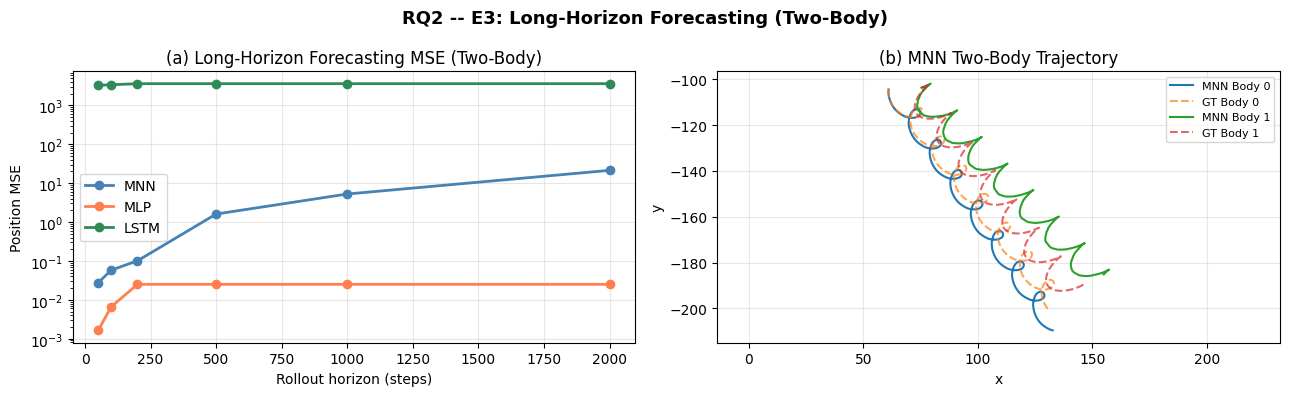

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
for name in df_e3.model.unique():
    sub = df_e3[df_e3.model==name].sort_values('horizon')
    ax.plot(sub.horizon, sub.mse, marker='o', label=name,
            color=MC.get(name,'grey'), linewidth=2)
ax.set(xlabel='Rollout horizon (steps)', ylabel='Position MSE',
       yscale='log', title='(a) Long-Horizon Forecasting MSE (Two-Body)')
ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
nstep = min(2000, mnn_pos.shape[0])
for i in range(NB):
    ax.plot(mnn_pos[:nstep, i, 0], mnn_pos[:nstep, i, 1],
            label=f'MNN Body {i}', linewidth=1.5)
    ax.plot(val_pos[NS:NS+nstep, i, 0], val_pos[NS:NS+nstep, i, 1],
            linestyle='--', alpha=0.7, label=f'GT Body {i}')
ax.set(title='(b) MNN Two-Body Trajectory', xlabel='x', ylabel='y')
ax.legend(fontsize=8); ax.axis('equal'); ax.grid(True, alpha=0.3)

fig.suptitle('RQ2 -- E3: Long-Horizon Forecasting (Two-Body)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq2_results/e3_forecasting.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E4 — Interpretability: MNN ODE Coefficients

Unique to MNN. Inspects: coeffs c0/c1/c2 over time, NeuRLP adaptive step sizes, phase portrait, reconstruction.

In [13]:
ds_interp = ControlledSineDataset(n_step=N_STEP, noise_std=NOISE, seed=0)
m_interp  = FlexMethod(n_step=N_STEP, lr=LR, seed=0)
make_trainer(N_EPOCHS, silent=False).fit(m_interp, datamodule=SineDataModule(ds_interp))

m_interp.eval()
with torch.no_grad():
    eps, u0, u1, u2, steps = m_interp()

coeffs_np = m_interp.model.coeffs.detach().cpu().squeeze().numpy()  # (500, 3)
steps_np  = torch.sigmoid(m_interp.model.steps).detach().cpu().squeeze().numpy()  # (499,)
u0_np = u0.detach().cpu().squeeze().numpy()
u1_np = u1.detach().cpu().squeeze().numpy()
u2_np = u2.detach().cpu().squeeze().numpy()
t_axis = np.linspace(0, N_STEP * 0.1, N_STEP)

print(f'coeffs shape: {coeffs_np.shape}  steps shape: {steps_np.shape}')
print(f'coeffs: c0={coeffs_np[:,0].mean():.4f}  c1={coeffs_np[:,1].mean():.4f}  c2={coeffs_np[:,2].mean():.4f}')

Using double precision solver
Building block diagonal A


GPU available: False, used: False
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  1.98it/s, v_num=132, train_loss=88.40, eps=0.00804]

`Trainer.fit` stopped: `max_epochs=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00,  1.90it/s, v_num=132, train_loss=88.40, eps=0.00804]
coeffs shape: (500, 3)  steps shape: (499,)
coeffs: c0=0.5266  c1=0.5917  c2=0.4810


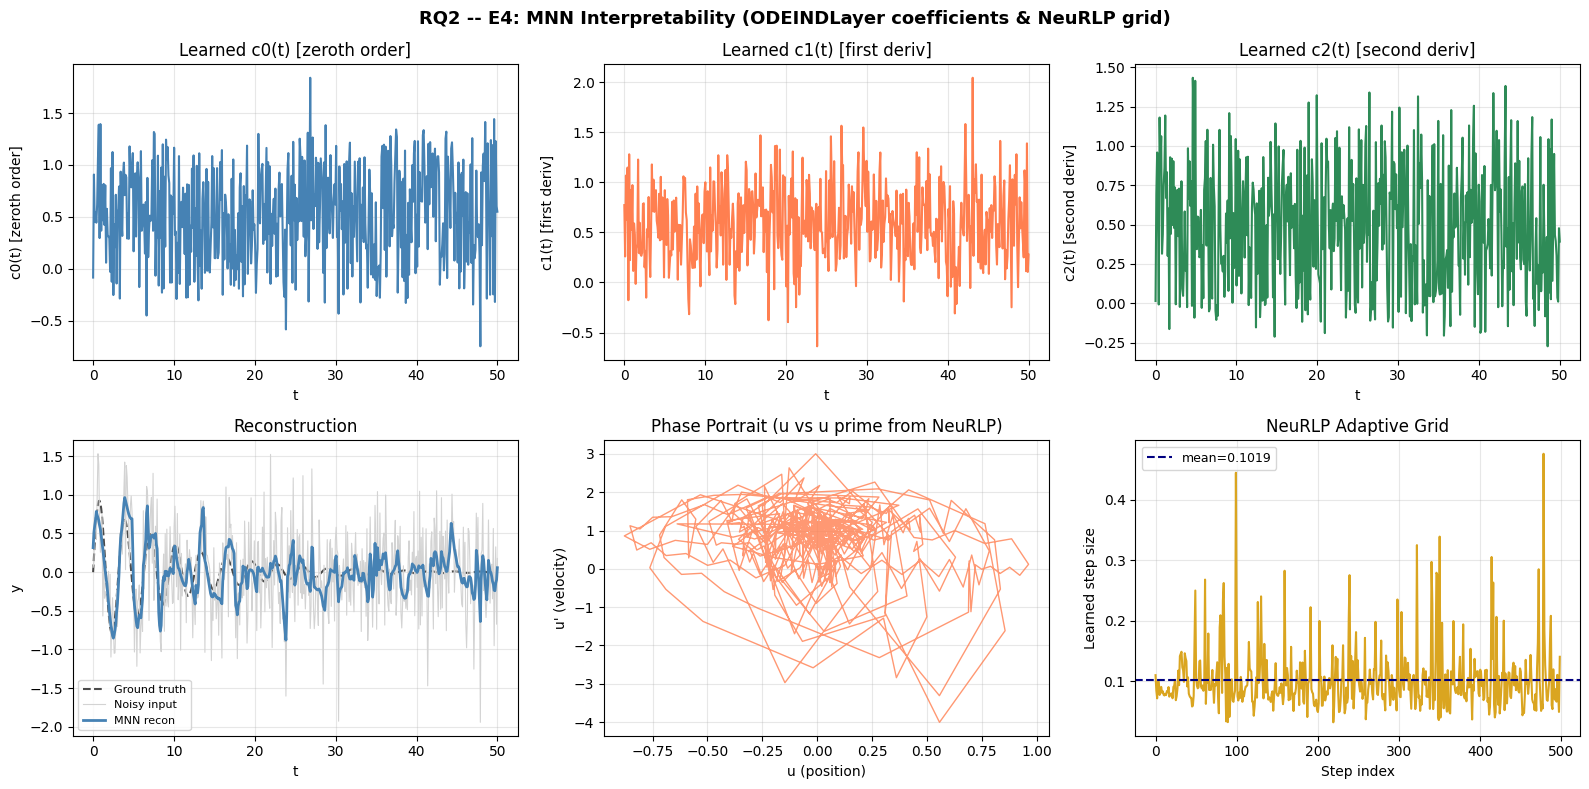

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
coeff_labels = ['c0(t) [zeroth order]', 'c1(t) [first deriv]', 'c2(t) [second deriv]']
coeff_colors = ['steelblue', 'coral', 'seagreen']

for i, (label, col) in enumerate(zip(coeff_labels, coeff_colors)):
    ax = axes[0, i]
    ax.plot(t_axis, coeffs_np[:, i], color=col, linewidth=1.5)
    ax.set(xlabel='t', ylabel=label, title=f'Learned {label}')
    ax.grid(True, alpha=0.3)

ax = axes[1, 0]
ax.plot(t_axis, ds_interp.clean.numpy(), 'k--', linewidth=1.5, label='Ground truth', alpha=0.7)
ax.plot(t_axis, ds_interp.y.numpy(),     color='lightgrey', linewidth=0.8, label='Noisy input')
ax.plot(t_axis, u0_np,                   color='steelblue', linewidth=2,   label='MNN recon')
ax.set(xlabel='t', ylabel='y', title='Reconstruction')
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

ax = axes[1, 1]
ax.plot(u0_np, u1_np, color='coral', linewidth=1, alpha=0.8)
ax.set(xlabel='u (position)', ylabel="u' (velocity)", title='Phase Portrait (u vs u prime from NeuRLP)')
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.plot(steps_np, color='goldenrod', linewidth=1.5)
ax.axhline(steps_np.mean(), linestyle='--', color='navy', linewidth=1.5,
           label=f'mean={steps_np.mean():.4f}')
ax.set(xlabel='Step index', ylabel='Learned step size',
       title='NeuRLP Adaptive Grid')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('RQ2 -- E4: MNN Interpretability (ODEINDLayer coefficients & NeuRLP grid)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq2_results/e4_interpretability.png', dpi=150, bbox_inches='tight')
plt.show()

---
## E5 — Training Efficiency & Parameter Count

Using double precision solver
Building block diagonal A
Epoch 3:   3%|▎         | 2/63 [1:07:12<34:09:52,  0.00it/s, v_num=130, train_loss_step=0.0141, train_loss_epoch=0.0151]


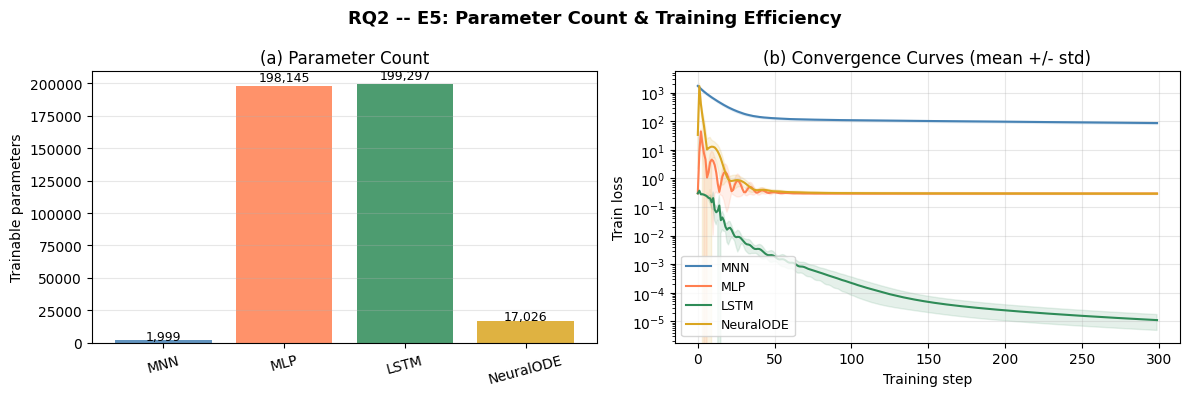

    model  n_params
      MNN      1999
      MLP    198145
     LSTM    199297
NeuralODE     17026


In [15]:
param_records = []
for name, method in make_all_methods(N_STEP).items():
    model_obj = method.model if hasattr(method, 'model') else method
    param_records.append({'model':name, 'n_params': count_params(model_obj)})
df_params = pd.DataFrame(param_records).set_index('model').loc[ORDER].reset_index()
df_params.to_csv('rq2_results/e5_params.csv', index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.bar(df_params.model, df_params.n_params,
       color=[MC[m] for m in df_params.model], alpha=0.85)
for i, row in df_params.iterrows():
    ax.text(i, row.n_params * 1.02, f'{row.n_params:,}', ha='center', fontsize=9)
ax.set(ylabel='Trainable parameters', title='(a) Parameter Count')
ax.tick_params(axis='x', rotation=15); ax.grid(True, axis='y', alpha=0.3)

ax = axes[1]
for name in ORDER:
    curves = e1_histories[name]
    if curves:
        arr = np.array([c for c in curves if len(c) == len(curves[0])])
        if arr.ndim == 2:
            mn = arr.mean(axis=0)
            ax.plot(mn, color=MC[name], linewidth=1.5, label=name)
            ax.fill_between(range(len(mn)), mn-arr.std(axis=0), mn+arr.std(axis=0),
                            alpha=0.12, color=MC[name])
ax.set(xlabel='Training step', ylabel='Train loss', yscale='log',
       title='(b) Convergence Curves (mean +/- std)')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

fig.suptitle('RQ2 -- E5: Parameter Count & Training Efficiency', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('rq2_results/e5_efficiency.png', dpi=150, bbox_inches='tight')
plt.show()
print(df_params.to_string(index=False))

---
## Final Summary

In [16]:
print('=== RQ2 Full Summary ===')
print('\n(E1) In-Distribution MSE:')
print(df_e1g[['model','mse_mean','mse_std','time_mean']].to_string(index=False))
print('\n(E2) OOD Generalisation:')
print(df_e2g[['model','id_mean','ood_mean','ratio_mean']].to_string(index=False))
print('\n(E3) Long-Horizon Forecasting MSE:')
print(df_e3.pivot(index='model', columns='horizon', values='mse').to_string())
print('\n(E5) Parameter Count:')
print(df_params.to_string(index=False))

df_e1g.to_csv('rq2_results/e1_indistribution.csv', index=False)
df_e2g.to_csv('rq2_results/e2_ood.csv', index=False)
df_e3.to_csv('rq2_results/e3_forecasting.csv', index=False)
df_params.to_csv('rq2_results/e5_params.csv', index=False)
print('\nAll CSVs saved to rq2_results/')

=== RQ2 Full Summary ===

(E1) In-Distribution MSE:
    model  mse_mean  mse_std  time_mean
      MNN  0.048115 0.007380  78.282389
      MLP  0.049832 0.000426   8.579867
     LSTM  0.245565 0.020783 154.419063
NeuralODE  0.052952 0.002240  44.162812

(E2) OOD Generalisation:
    model  id_mean  ood_mean  ratio_mean
      MNN 0.048115  0.249980    5.289198
      MLP 0.049832  0.447203    8.974388
     LSTM 0.245565  0.245776    1.008415
NeuralODE 0.052952  0.449411    8.496896

(E3) Long-Horizon Forecasting MSE:
horizon         50           100          200          500          1000         2000
model                                                                                
LSTM     3280.437256  3390.912598  3615.266357  3615.266357  3615.266357  3615.266357
MLP         0.001638     0.006644     0.025042     0.025042     0.025042     0.025042
MNN         0.027584     0.058030     0.100911     1.607024     5.259143    21.342993

(E5) Parameter Count:
    model  n_params
      MN